<a href="https://colab.research.google.com/github/arafatro/IntroToDS/blob/main/Practice%20Materials/Week%206/DS_Practice_FeatureSelection_DimReduction_Scaling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction to Data Science
## Practice Session — Feature Selection, Dimensionality Reduction & Scaling
**Eötvös Loránd University (ELTE) · Faculty of Informatics**

---
**Instructor:** Arafat Md Easin  
**Goal:** By the end of this session you will be able to:
- Understand **why** feature selection, scaling, and dimensionality reduction matter before modelling
- Apply **filter, wrapper, and embedded** feature selection methods
- Scale features correctly using **StandardScaler, MinMaxScaler, and RobustScaler**
- Reduce high-dimensional data to 2D using **PCA** and visualise the result
- Combine all steps into a **clean preprocessing pipeline**

> **Tip:** Run each cell with `Shift + Enter` and read the comments carefully before moving on.  
> **Key principle:** Preprocessing is not cosmetic — the wrong scaler or too many irrelevant features will quietly sabotage your model.

---

## Part 0 — Setup & Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer, load_wine
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.feature_selection import (
    SelectKBest, f_classif, mutual_info_classif,
    RFE, SelectFromModel
)
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

# ── Reproducible randomness ───────────────────────────────────────────
RNG = np.random.default_rng(seed=42)

# ── Plot style ────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"]    = 110
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

print("Setup complete.")

Setup complete.


In [2]:
# ── Load datasets ─────────────────────────────────────────────────────
# We use two classic sklearn datasets:
#   breast_cancer — 30 features, binary target (malignant / benign)
#   wine          — 13 features, 3-class target (wine cultivar)

# Breast Cancer dataset
bc = load_breast_cancer()
X_bc = pd.DataFrame(bc.data, columns=bc.feature_names)
y_bc = pd.Series(bc.target, name="target")   # 0 = malignant, 1 = benign

# Wine dataset
wine = load_wine()
X_wine = pd.DataFrame(wine.data, columns=wine.feature_names)
y_wine = pd.Series(wine.target, name="cultivar")

print("=== Breast Cancer ===")
print(f"  Samples: {X_bc.shape[0]},  Features: {X_bc.shape[1]}")
print(f"  Classes: {dict(zip(bc.target_names, np.bincount(y_bc)))}")
print()
print("=== Wine ===")
print(f"  Samples: {X_wine.shape[0]},  Features: {X_wine.shape[1]}")
print(f"  Classes: {dict(zip(wine.target_names, np.bincount(y_wine)))}")
print()
X_bc.describe().round(2)

=== Breast Cancer ===
  Samples: 569,  Features: 30
  Classes: {np.str_('malignant'): np.int64(212), np.str_('benign'): np.int64(357)}

=== Wine ===
  Samples: 178,  Features: 13
  Classes: {np.str_('class_0'): np.int64(59), np.str_('class_1'): np.int64(71), np.str_('class_2'): np.int64(48)}



,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,...,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00
mean,14.13,19.29,91.97,654.89,0.10,0.10,0.09,0.05,0.18,0.06,...,16.27,25.68,107.26,880.58,0.13,0.25,0.27,0.11,0.29,0.08
std,3.52,4.30,24.30,351.91,0.01,0.05,0.08,0.04,0.03,0.01,...,4.83,6.15,33.60,569.36,0.02,0.16,0.21,0.07,0.06,0.02
min,6.98,9.71,43.79,143.50,0.05,0.02,0.00,0.00,0.11,0.05,...,7.93,12.02,50.41,185.20,0.07,0.03,0.00,0.00,0.16,0.06
25%,11.70,16.17,75.17,420.30,0.09,0.06,0.03,0.02,0.16,0.06,...,13.01,21.08,84.11,515.30,0.12,0.15,0.11,0.06,0.25,0.07
50%,13.37,18.84,86.24,551.10,0.10,0.09,0.06,0.03,0.18,0.06,...,14.97,25.41,97.66,686.50,0.13,0.21,0.23,0.10,0.28,0.08
75%,15.78,21.80,104.10,782.70,0.11,0.13,0.13,0.07,0.20,0.07,...,18.79,29.72,125.40,1084.00,0.15,0.34,0.38,0.16,0.32,0.09
max,28.11,39.28,188.50,2501.00,0.16,0.35,0.43,0.20,0.30,0.10,...,36.04,49.54,251.20,4254.00,0.22,1.06,1.25,0.29,0.66,0.21


---
## Part 1 — Why Preprocessing Matters

Before touching any model, you need to understand three related problems:

| Problem | Symptom | Solution |
|---|---|---|
| **Features on different scales** | Distance-based models (KNN, SVM, PCA) are dominated by large-valued features | **Feature scaling** |
| **Too many irrelevant features** | Model overfits, training is slow, interpretation is hard | **Feature selection** |
| **Too many features to visualise or model** | The curse of dimensionality — data becomes sparse in high dimensions | **Dimensionality reduction** |

> **The curse of dimensionality:** As the number of features grows, the volume of the feature space grows exponentially. Data points become farther and farther apart — your nearest neighbours are no longer actually "near". Models that work in 5 dimensions can completely fail in 50.

The typical preprocessing order is:
1. Handle missing values  
2. **Scale** features  
3. **Select** relevant features (or reduce dimensions)  
4. Model

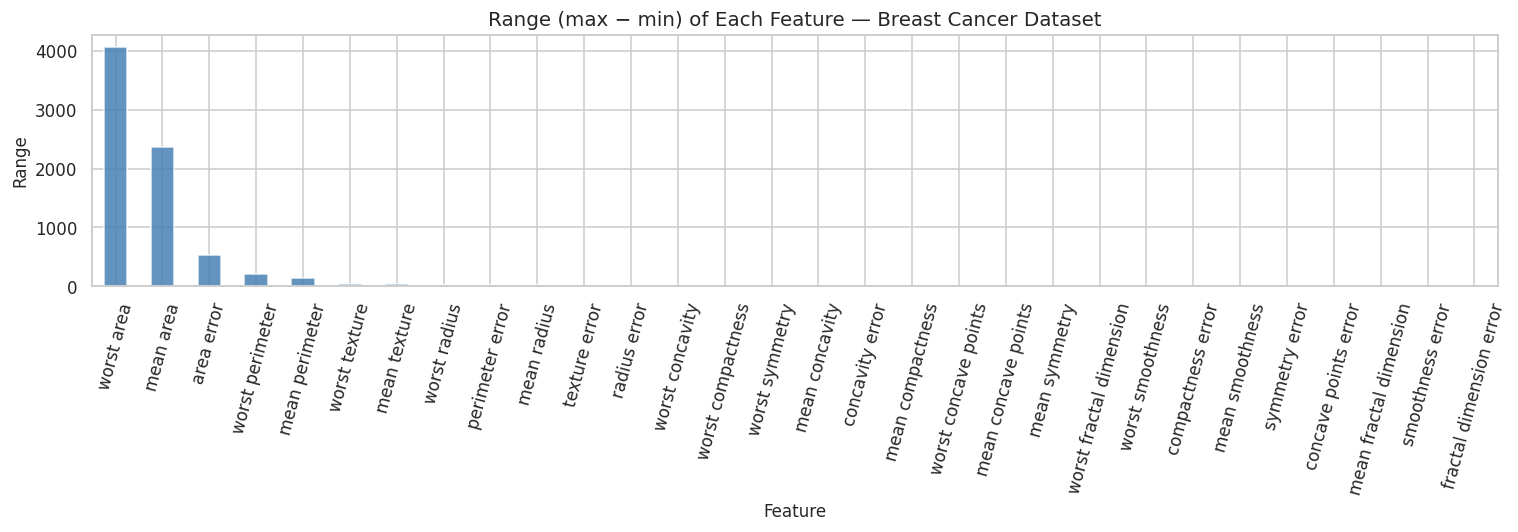

Largest range:  worst area = 4068.8
Smallest range: fractal dimension error = 0.02895

The largest feature has a range ~10,000× the smallest.
Without scaling, any model using distances or gradients will be dominated by the largest feature.


In [3]:
# ── 1.1  Visualise the raw scale problem ──────────────────────────────
# Look at the range of each feature in the breast cancer dataset.
# Features with large values will dominate distance-based calculations.

fig, ax = plt.subplots(figsize=(14, 5))

feature_ranges = X_bc.max() - X_bc.min()
feature_ranges.sort_values(ascending=False).plot(kind="bar", color="steelblue",
                                                  edgecolor="white", alpha=0.85, ax=ax)
ax.set_title("Range (max − min) of Each Feature — Breast Cancer Dataset", fontsize=13)
ax.set_xlabel("Feature")
ax.set_ylabel("Range")
ax.tick_params(axis="x", rotation=75)
plt.tight_layout()
plt.show()

print(f"Largest range:  {feature_ranges.idxmax()} = {feature_ranges.max():.1f}")
print(f"Smallest range: {feature_ranges.idxmin()} = {feature_ranges.min():.5f}")
print("\nThe largest feature has a range ~10,000× the smallest.")
print("Without scaling, any model using distances or gradients will be dominated by the largest feature.")

---
## Part 2 — Feature Scaling

Scaling transforms all features to a comparable numerical range **without distorting the information they carry**.

Three scalers, three use cases:

| Scaler | Formula | Best when |
|---|---|---|
| **StandardScaler** | $(x - \mu) / \sigma$ | Data is roughly Gaussian; you want zero mean, unit variance |
| **MinMaxScaler** | $(x - x_{min}) / (x_{max} - x_{min})$ | You need values in $[0, 1]$; no heavy outliers |
| **RobustScaler** | $(x - Q_2) / (Q_3 - Q_1)$ | Data has outliers; uses median & IQR instead of mean & std |

> **Critical rule:** Fit the scaler on the **training set only**, then apply it to the test set. Never fit on test data — this leaks information.

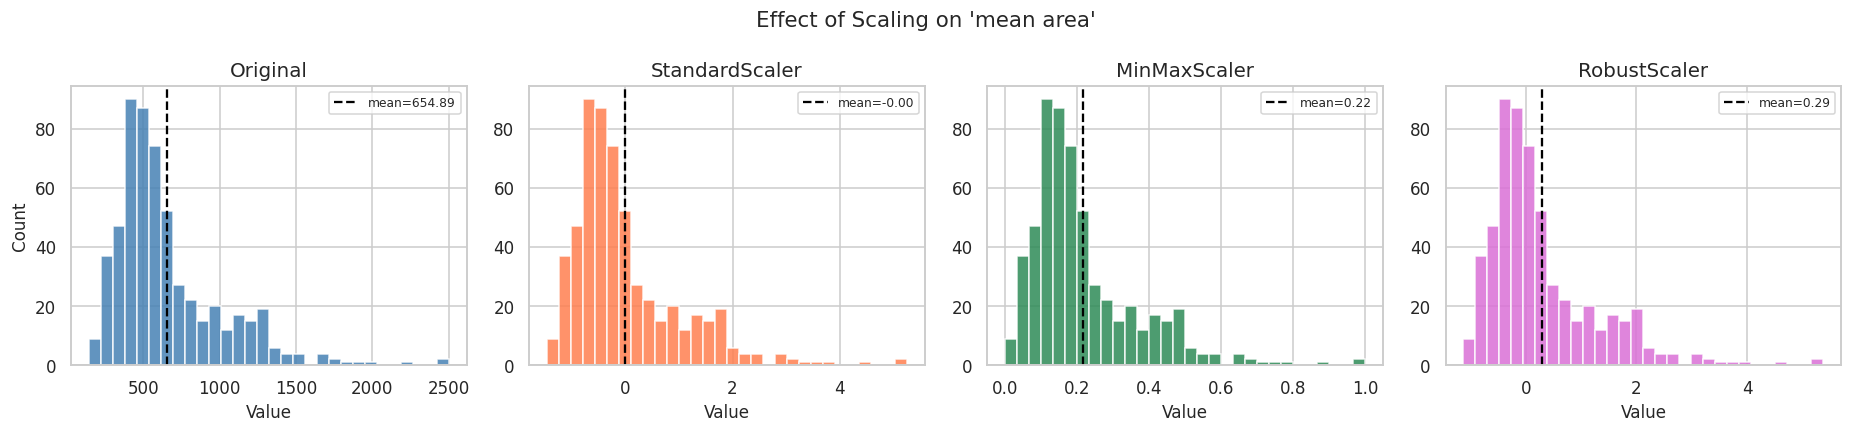

StandardScaler → mean ≈ 0, std = 1
MinMaxScaler   → all values in [0, 1]
RobustScaler   → median ≈ 0, scaled by IQR — outliers are compressed but not removed


In [4]:
# ── 2.1  Comparing the three scalers on one feature ───────────────────
# We will use 'mean area' — a feature with a large range and some outliers.

feature = "mean area"
x_raw = X_bc[[feature]].values

scalers = {
    "Original": x_raw,
    "StandardScaler": StandardScaler().fit_transform(x_raw),
    "MinMaxScaler":   MinMaxScaler().fit_transform(x_raw),
    "RobustScaler":   RobustScaler().fit_transform(x_raw),
}

fig, axes = plt.subplots(1, 4, figsize=(17, 4))
fig.suptitle(f"Effect of Scaling on '{feature}'", fontsize=14)

colors = ["steelblue", "coral", "seagreen", "orchid"]
for ax, (name, data), color in zip(axes, scalers.items(), colors):
    ax.hist(data, bins=30, color=color, edgecolor="white", alpha=0.85)
    ax.set_title(name)
    ax.set_xlabel("Value")
    ax.set_ylabel("Count" if ax == axes[0] else "")
    ax.axvline(np.mean(data), color="black", linestyle="--", linewidth=1.5,
               label=f"mean={np.mean(data):.2f}")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print("StandardScaler → mean ≈ 0, std = 1")
print("MinMaxScaler   → all values in [0, 1]")
print("RobustScaler   → median ≈ 0, scaled by IQR — outliers are compressed but not removed")

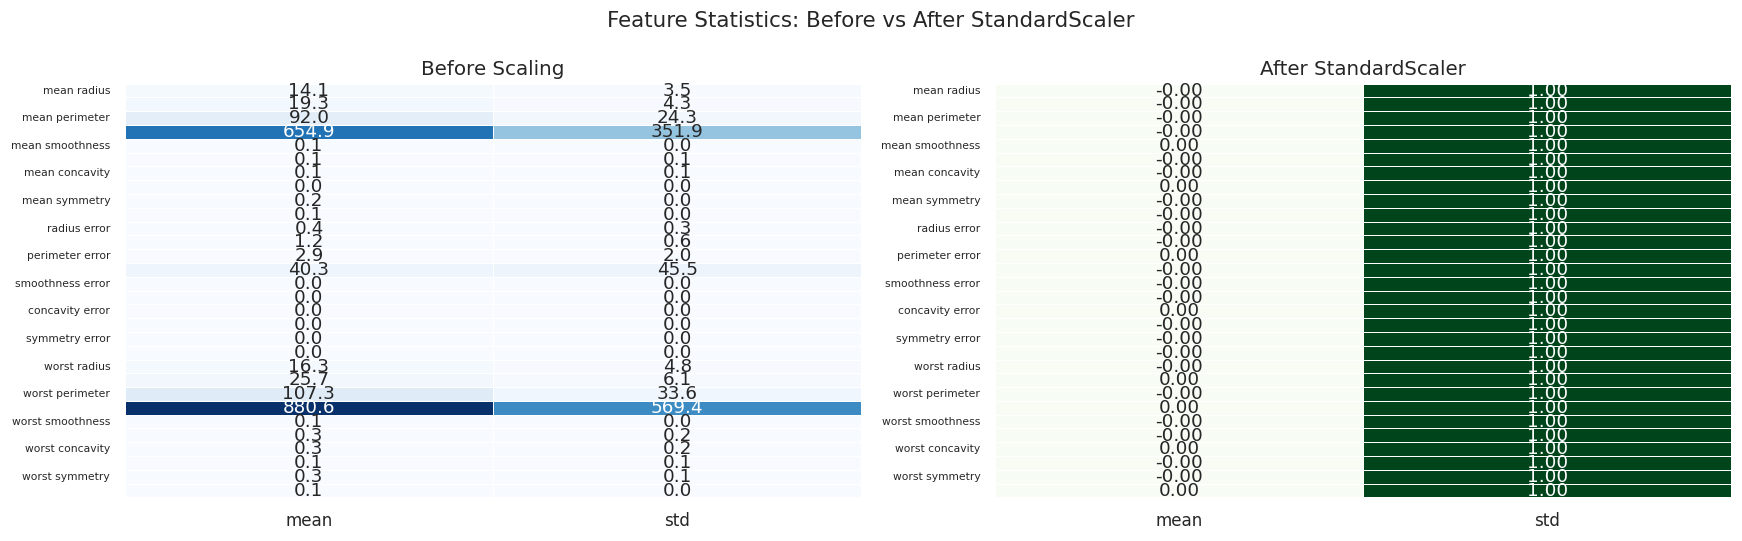

After StandardScaler: all means ≈ 0, all stds ≈ 1.
No single feature now dominates by virtue of its raw numeric scale.


In [5]:
# ── 2.2  Scaling all features — before vs after ───────────────────────
# A heatmap of feature means and stds shows the transformation clearly.

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_bc), columns=X_bc.columns)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Feature Statistics: Before vs After StandardScaler", fontsize=14)

before_stats = X_bc.agg(["mean", "std"]).T
after_stats  = X_scaled.agg(["mean", "std"]).T

sns.heatmap(before_stats, annot=True, fmt=".1f", cmap="Blues",
            linewidths=0.5, ax=axes[0], cbar=False)
axes[0].set_title("Before Scaling")
axes[0].tick_params(axis="y", labelsize=7)

sns.heatmap(after_stats, annot=True, fmt=".2f", cmap="Greens",
            linewidths=0.5, ax=axes[1], cbar=False)
axes[1].set_title("After StandardScaler")
axes[1].tick_params(axis="y", labelsize=7)

plt.tight_layout()
plt.show()

print("After StandardScaler: all means ≈ 0, all stds ≈ 1.")
print("No single feature now dominates by virtue of its raw numeric scale.")

### Exercise 1
Using the **Wine dataset** (`X_wine`, `y_wine`):

1. Plot a bar chart of the **range** (max − min) for each of the 13 features.
2. Apply **all three scalers** to the feature `"alcohol"` and plot the resulting distributions side by side (1 row, 4 panels including the original).
3. Which scaler would you choose for this feature and why? Write your reasoning in a text cell.
4. Apply `MinMaxScaler` to all 13 features and print the min and max of the scaled data to confirm all values are in $[0, 1]$.

```python
# Your code here
```

```
# Your answer here
```

---
## Part 3 — Feature Selection

Feature selection removes features that add **noise, redundancy, or complexity** without adding predictive power.

Three families of methods:

| Family | How it works | Example |
|---|---|---|
| **Filter** | Score each feature independently of any model | ANOVA F-score, Mutual Information |
| **Wrapper** | Train a model repeatedly, selecting the best feature subset | Recursive Feature Elimination (RFE) |
| **Embedded** | Feature selection is built into the model's training process | L1 (Lasso) regularisation, Random Forest importance |

> **Rule of thumb:** Start with a filter method (fast, model-agnostic), then refine with an embedded or wrapper method if needed.

### 3.1 Filter Methods

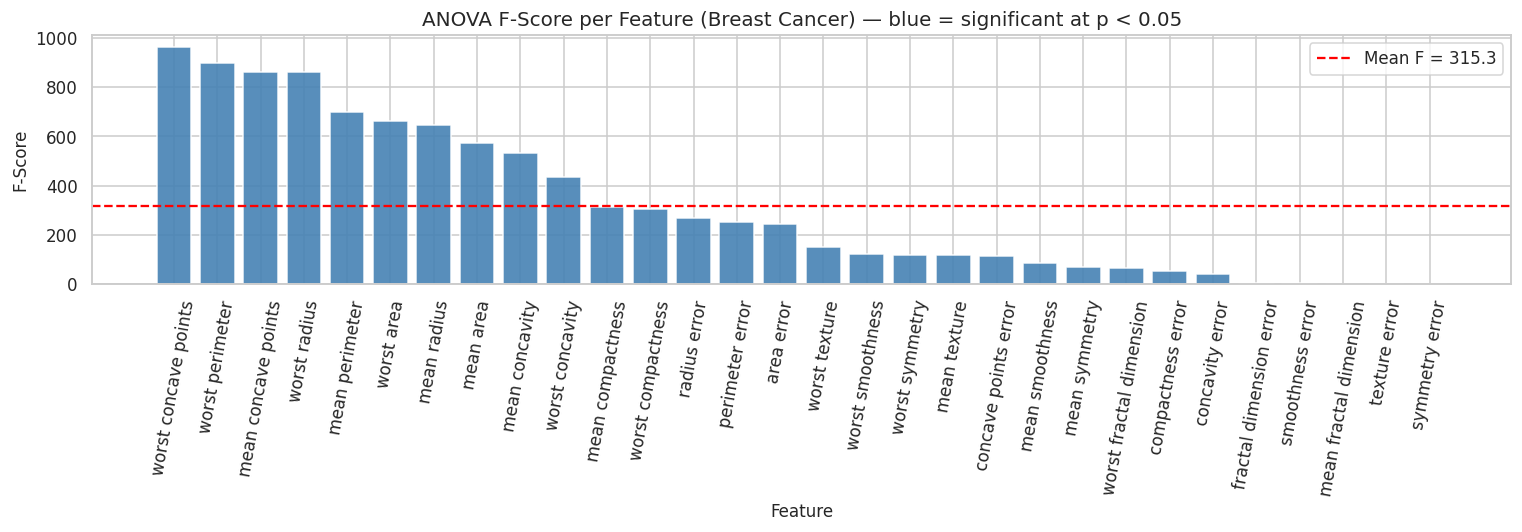

Top 5 features by F-score:
             feature    f_score       p_value
worst concave points 964.385393 1.969100e-124
     worst perimeter 897.944219 5.771397e-119
 mean concave points 861.676020 7.101150e-116
        worst radius 860.781707 8.482292e-116
      mean perimeter 697.235272 8.436251e-101


In [6]:
# ── 3.1a  ANOVA F-score: how well does each feature separate the classes? ──
# F-score measures the ratio of variance between classes to variance within classes.
# High F-score → the feature is informative for classification.

X_sc = StandardScaler().fit_transform(X_bc)   # always scale before selection

f_scores, p_values = f_classif(X_sc, y_bc)

f_df = pd.DataFrame({
    "feature": X_bc.columns,
    "f_score": f_scores,
    "p_value": p_values
}).sort_values("f_score", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 5))

colors = ["steelblue" if p < 0.05 else "lightgrey" for p in f_df["p_value"]]
ax.bar(f_df["feature"], f_df["f_score"], color=colors, edgecolor="white", alpha=0.9)
ax.axhline(f_df["f_score"].mean(), color="red", linestyle="--", linewidth=1.5,
           label=f"Mean F = {f_df['f_score'].mean():.1f}")
ax.set_title("ANOVA F-Score per Feature (Breast Cancer) — blue = significant at p < 0.05")
ax.set_xlabel("Feature")
ax.set_ylabel("F-Score")
ax.tick_params(axis="x", rotation=80)
ax.legend()
plt.tight_layout()
plt.show()

print("Top 5 features by F-score:")
print(f_df[["feature", "f_score", "p_value"]].head(5).to_string(index=False))

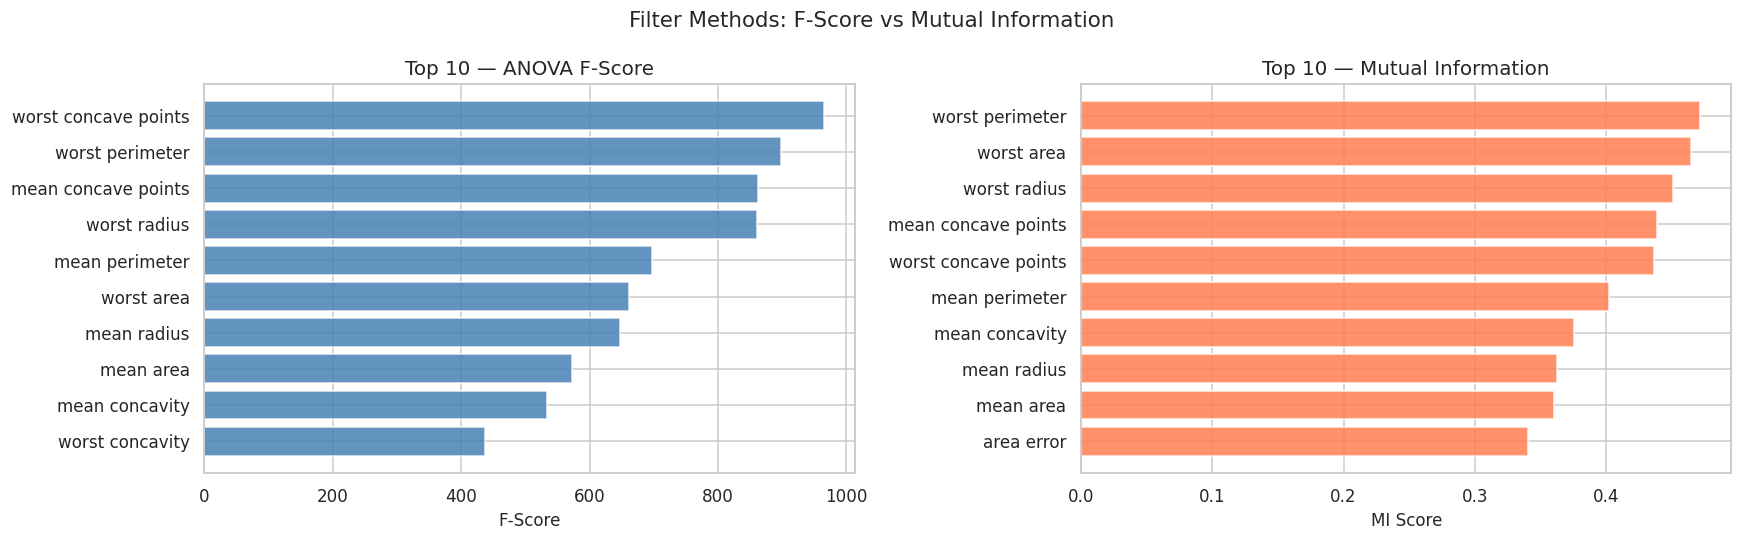

Features in both top-10 lists: {'mean radius', 'worst radius', 'worst perimeter', 'mean area', 'mean concave points', 'worst concave points', 'mean concavity', 'worst area', 'mean perimeter'}
Features only in F-score top-10: {'worst concavity'}
Features only in MI top-10: {'area error'}


In [7]:
# ── 3.1b  Mutual Information: captures non-linear dependencies ─────────
# MI measures how much knowing a feature reduces uncertainty about the target.
# Unlike F-score, it detects non-linear relationships too.

mi_scores = mutual_info_classif(X_sc, y_bc, random_state=42)

mi_df = pd.DataFrame({
    "feature": X_bc.columns,
    "mi_score": mi_scores
}).sort_values("mi_score", ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Filter Methods: F-Score vs Mutual Information", fontsize=14)

# F-score ranking
axes[0].barh(f_df["feature"][:10][::-1], f_df["f_score"][:10][::-1],
             color="steelblue", edgecolor="white", alpha=0.85)
axes[0].set_title("Top 10 — ANOVA F-Score")
axes[0].set_xlabel("F-Score")

# MI ranking
axes[1].barh(mi_df["feature"][:10][::-1], mi_df["mi_score"][:10][::-1],
             color="coral", edgecolor="white", alpha=0.85)
axes[1].set_title("Top 10 — Mutual Information")
axes[1].set_xlabel("MI Score")

plt.tight_layout()
plt.show()

# How much do the two methods agree on the top 10?
top10_f  = set(f_df["feature"][:10])
top10_mi = set(mi_df["feature"][:10])
print(f"Features in both top-10 lists: {top10_f & top10_mi}")
print(f"Features only in F-score top-10: {top10_f - top10_mi}")
print(f"Features only in MI top-10: {top10_mi - top10_f}")

In [8]:
# ── 3.1c  SelectKBest: automatically keep the top k features ──────────

k = 10
selector = SelectKBest(score_func=f_classif, k=k)
X_kbest  = selector.fit_transform(X_sc, y_bc)

selected_mask     = selector.get_support()
selected_features = X_bc.columns[selected_mask].tolist()

print(f"Original shape: {X_sc.shape}")
print(f"After SelectKBest (k={k}): {X_kbest.shape}")
print(f"\nSelected features:")
for i, feat in enumerate(selected_features, 1):
    print(f"  {i:2d}. {feat}")

Original shape: (569, 30)
After SelectKBest (k=10): (569, 10)

Selected features:
   1. mean radius
   2. mean perimeter
   3. mean area
   4. mean concavity
   5. mean concave points
   6. worst radius
   7. worst perimeter
   8. worst area
   9. worst concavity
  10. worst concave points


### 3.2 Wrapper Method — Recursive Feature Elimination (RFE)

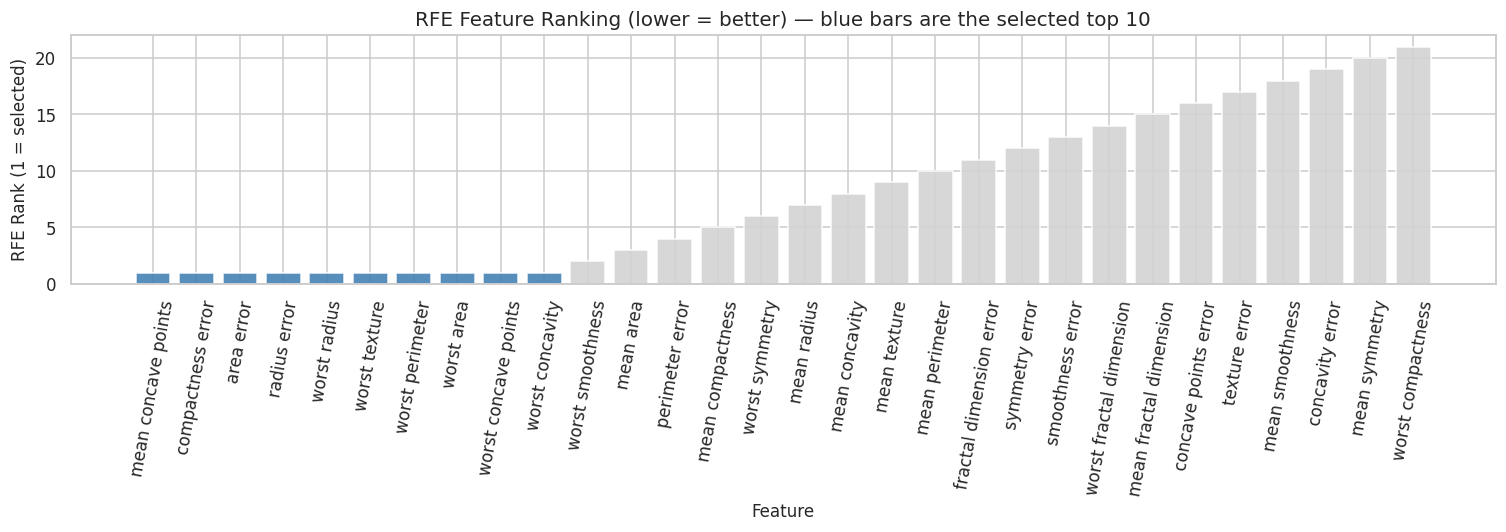

RFE selected features: ['mean concave points', 'compactness error', 'area error', 'radius error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst concave points', 'worst concavity']

Features selected by BOTH F-score filter and RFE: {'worst concavity', 'worst radius', 'worst perimeter', 'mean concave points', 'worst concave points', 'worst area'}


In [9]:
# ── 3.2  RFE with Logistic Regression ─────────────────────────────────
# RFE:
#   1. Trains the model on all features.
#   2. Removes the least important feature.
#   3. Repeats until the desired number of features remains.
# More thorough than filter methods but slower — it retrains the model each step.

log_reg = LogisticRegression(max_iter=5000, random_state=42)
rfe = RFE(estimator=log_reg, n_features_to_select=10, step=1)
rfe.fit(X_sc, y_bc)

rfe_df = pd.DataFrame({
    "feature": X_bc.columns,
    "selected": rfe.support_,
    "rank":     rfe.ranking_
}).sort_values("rank")

fig, ax = plt.subplots(figsize=(14, 5))

bar_colors = ["steelblue" if s else "lightgrey" for s in rfe_df["selected"]]
ax.bar(rfe_df["feature"], rfe_df["rank"], color=bar_colors, edgecolor="white", alpha=0.9)
ax.set_title("RFE Feature Ranking (lower = better) — blue bars are the selected top 10")
ax.set_xlabel("Feature")
ax.set_ylabel("RFE Rank (1 = selected)")
ax.tick_params(axis="x", rotation=80)
plt.tight_layout()
plt.show()

rfe_selected = rfe_df[rfe_df["selected"]]["feature"].tolist()
print("RFE selected features:", rfe_selected)

# Agreement with filter method
print(f"\nFeatures selected by BOTH F-score filter and RFE: {set(selected_features) & set(rfe_selected)}")

### 3.3 Embedded Method — Random Forest Feature Importance

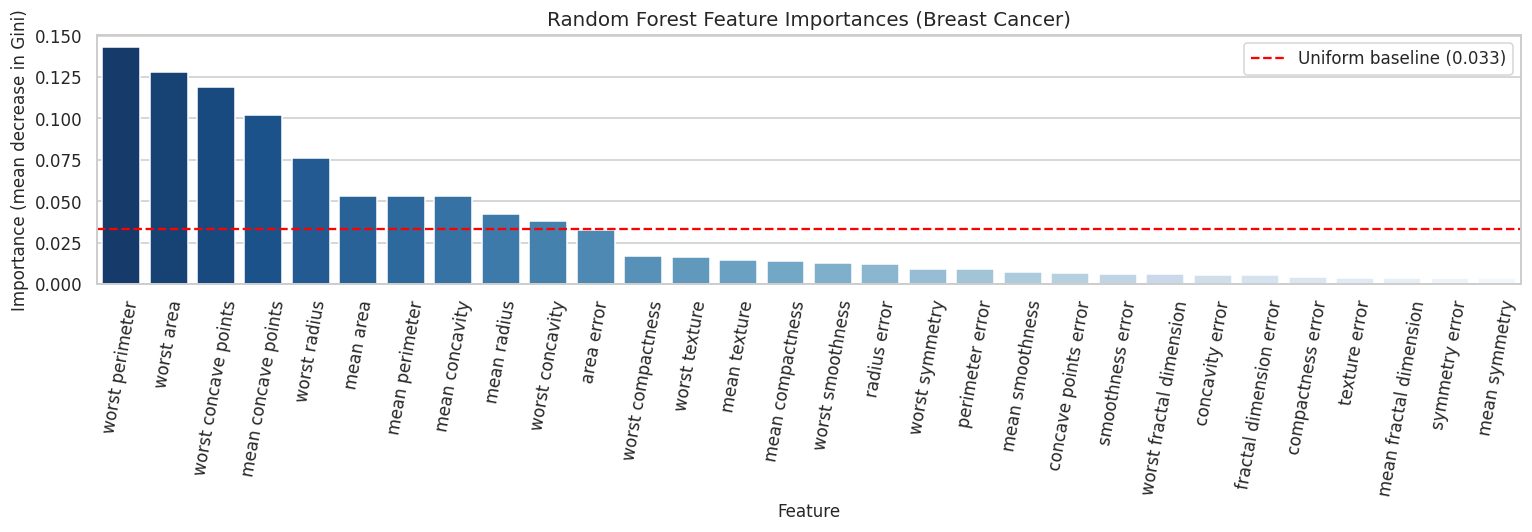

Top 10 features by Random Forest importance:
             feature  importance
     worst perimeter    0.143298
          worst area    0.128118
worst concave points    0.119072
 mean concave points    0.102228
        worst radius    0.076250
           mean area    0.053145
      mean perimeter    0.053057
      mean concavity    0.052886
         mean radius    0.042239
     worst concavity    0.037786


In [10]:
# ── 3.3  Random Forest Feature Importance ─────────────────────────────
# Random Forests compute feature importance internally during training.
# Importance = mean decrease in impurity (Gini) across all trees and splits.
# No extra training runs required — the selection is free.

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_sc, y_bc)

rf_importance = pd.DataFrame({
    "feature":    X_bc.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 5))

sns.barplot(data=rf_importance, x="feature", y="importance",
            palette="Blues_r", edgecolor="white", ax=ax)
ax.axhline(1 / len(X_bc.columns), color="red", linestyle="--", linewidth=1.5,
           label=f"Uniform baseline ({1/len(X_bc.columns):.3f})")
ax.set_title("Random Forest Feature Importances (Breast Cancer)")
ax.set_xlabel("Feature")
ax.set_ylabel("Importance (mean decrease in Gini)")
ax.tick_params(axis="x", rotation=80)
ax.legend()
plt.tight_layout()
plt.show()

print("Top 10 features by Random Forest importance:")
print(rf_importance.head(10).to_string(index=False))

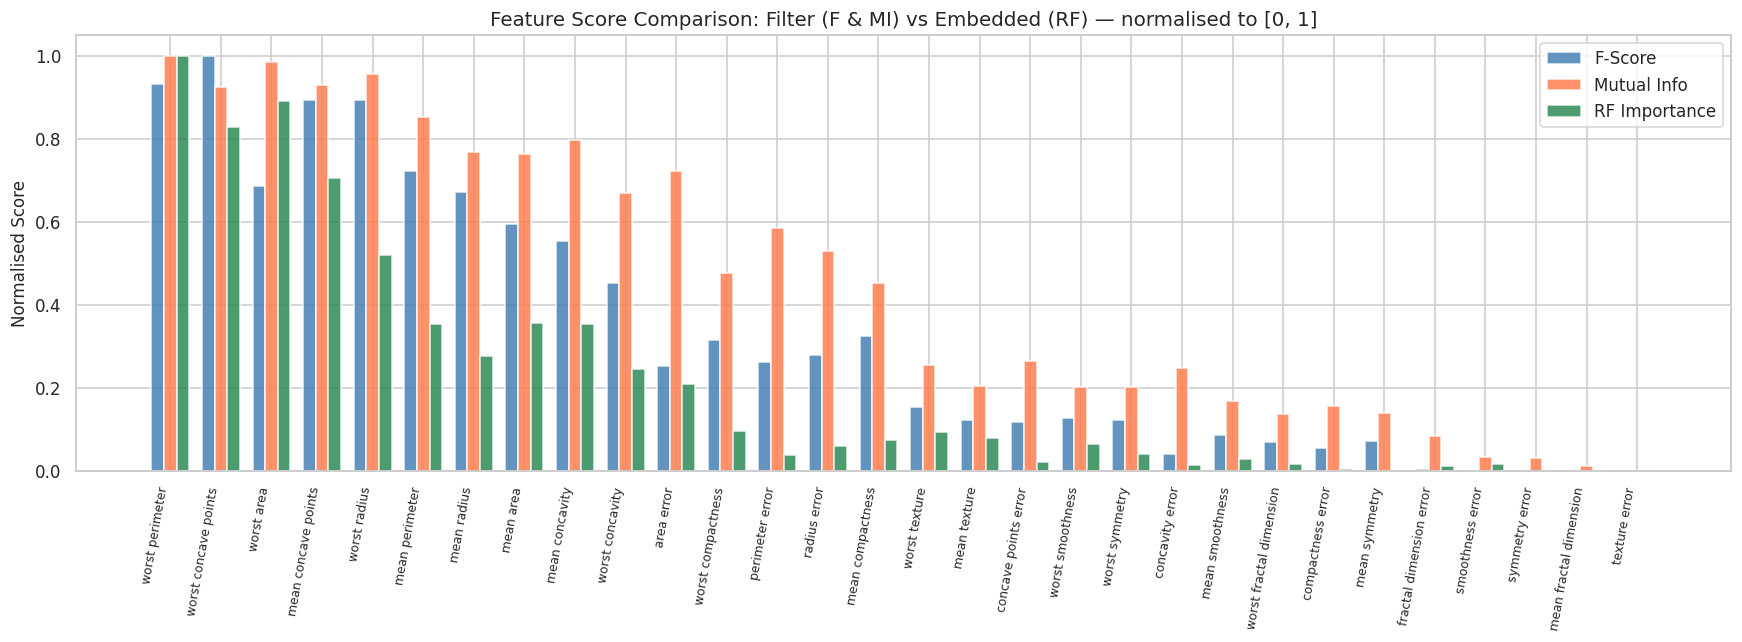

Consensus top-5 features (averaged across all three methods):
             feature  avg_score
     worst perimeter   0.977034
worst concave points   0.917115
          worst area   0.853841
 mean concave points   0.843263
        worst radius   0.789809


In [11]:
# ── 3.4  Comparing all three selection methods side by side ───────────

# Normalise each score to [0, 1] for a fair visual comparison
def norm01(series):
    return (series - series.min()) / (series.max() - series.min())

compare = pd.DataFrame({
    "feature":  X_bc.columns,
    "F_score":  norm01(pd.Series(f_scores)),
    "MI_score": norm01(pd.Series(mi_scores)),
    "RF_importance": norm01(pd.Series(rf.feature_importances_))
})

# Rank by average normalised score
compare["avg_score"] = compare[["F_score", "MI_score", "RF_importance"]].mean(axis=1)
compare = compare.sort_values("avg_score", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(16, 6))

x = np.arange(len(compare))
width = 0.25

ax.bar(x - width, compare["F_score"],        width, label="F-Score",       color="steelblue",  alpha=0.85)
ax.bar(x,         compare["MI_score"],        width, label="Mutual Info",   color="coral",      alpha=0.85)
ax.bar(x + width, compare["RF_importance"],   width, label="RF Importance", color="seagreen",   alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(compare["feature"], rotation=80, ha="right", fontsize=8)
ax.set_title("Feature Score Comparison: Filter (F & MI) vs Embedded (RF) — normalised to [0, 1]")
ax.set_ylabel("Normalised Score")
ax.legend()
plt.tight_layout()
plt.show()

print("Consensus top-5 features (averaged across all three methods):")
print(compare[["feature", "avg_score"]].head(5).to_string(index=False))

### Exercise 2
Using the **Wine dataset** (`X_wine`, `y_wine`, 13 features, 3 classes):

1. Scale the data with `StandardScaler`.
2. Apply `SelectKBest` with `f_classif` and `k=7`. Print which features are selected.
3. Compute **Random Forest feature importances** and plot them as a horizontal bar chart, sorted from most to least important.
4. Do both methods agree on the top 5 features? List the features that appear in both top-5 lists.
5. Write one sentence explaining why the two methods might rank features differently.

```python
# Your code here
```

```
# Your answer here
```

---
## Part 4 — Dimensionality Reduction with PCA

Feature selection **removes** features. Dimensionality reduction **transforms** all features into a smaller set of new variables that capture the most variance.

**Principal Component Analysis (PCA):**
- Finds the directions (principal components) of maximum variance in the data.
- PC1 captures the most variance, PC2 the second most, and so on.
- All PCs are **orthogonal** (uncorrelated).
- We can project 30 features down to 2 and still retain most of the information.

> **Important:** PCA requires scaled data. Because PCA is based on variance, large-scale features would dominate the components without scaling.

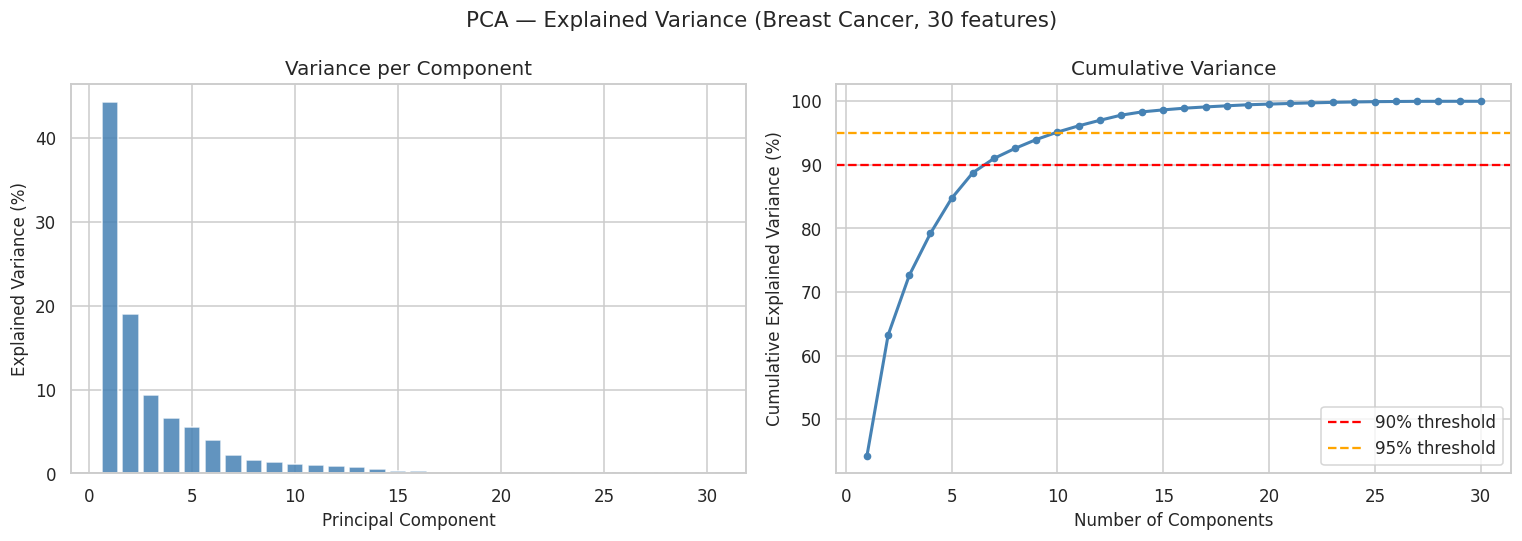

Components needed to explain 90% of variance: 7
Components needed to explain 95% of variance: 10
First component alone explains: 44.3% of variance
First two components explain:   63.2% of variance


In [12]:
# ── 4.1  Explained variance — how many components do we need? ─────────
# Fit PCA on all 30 scaled features and look at how variance is distributed
# across the components.

pca_full = PCA(random_state=42)
pca_full.fit(X_sc)

explained   = pca_full.explained_variance_ratio_
cumulative  = np.cumsum(explained)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("PCA — Explained Variance (Breast Cancer, 30 features)", fontsize=14)

# Individual component variance
axes[0].bar(range(1, len(explained) + 1), explained * 100,
            color="steelblue", edgecolor="white", alpha=0.85)
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance (%)")
axes[0].set_title("Variance per Component")

# Cumulative variance
axes[1].plot(range(1, len(cumulative) + 1), cumulative * 100,
             marker="o", color="steelblue", linewidth=2, markersize=4)
axes[1].axhline(90, color="red",    linestyle="--", linewidth=1.5, label="90% threshold")
axes[1].axhline(95, color="orange", linestyle="--", linewidth=1.5, label="95% threshold")
axes[1].set_xlabel("Number of Components")
axes[1].set_ylabel("Cumulative Explained Variance (%)")
axes[1].set_title("Cumulative Variance")
axes[1].legend()

plt.tight_layout()
plt.show()

n90 = np.argmax(cumulative >= 0.90) + 1
n95 = np.argmax(cumulative >= 0.95) + 1
print(f"Components needed to explain 90% of variance: {n90}")
print(f"Components needed to explain 95% of variance: {n95}")
print(f"First component alone explains: {explained[0]*100:.1f}% of variance")
print(f"First two components explain:   {cumulative[1]*100:.1f}% of variance")

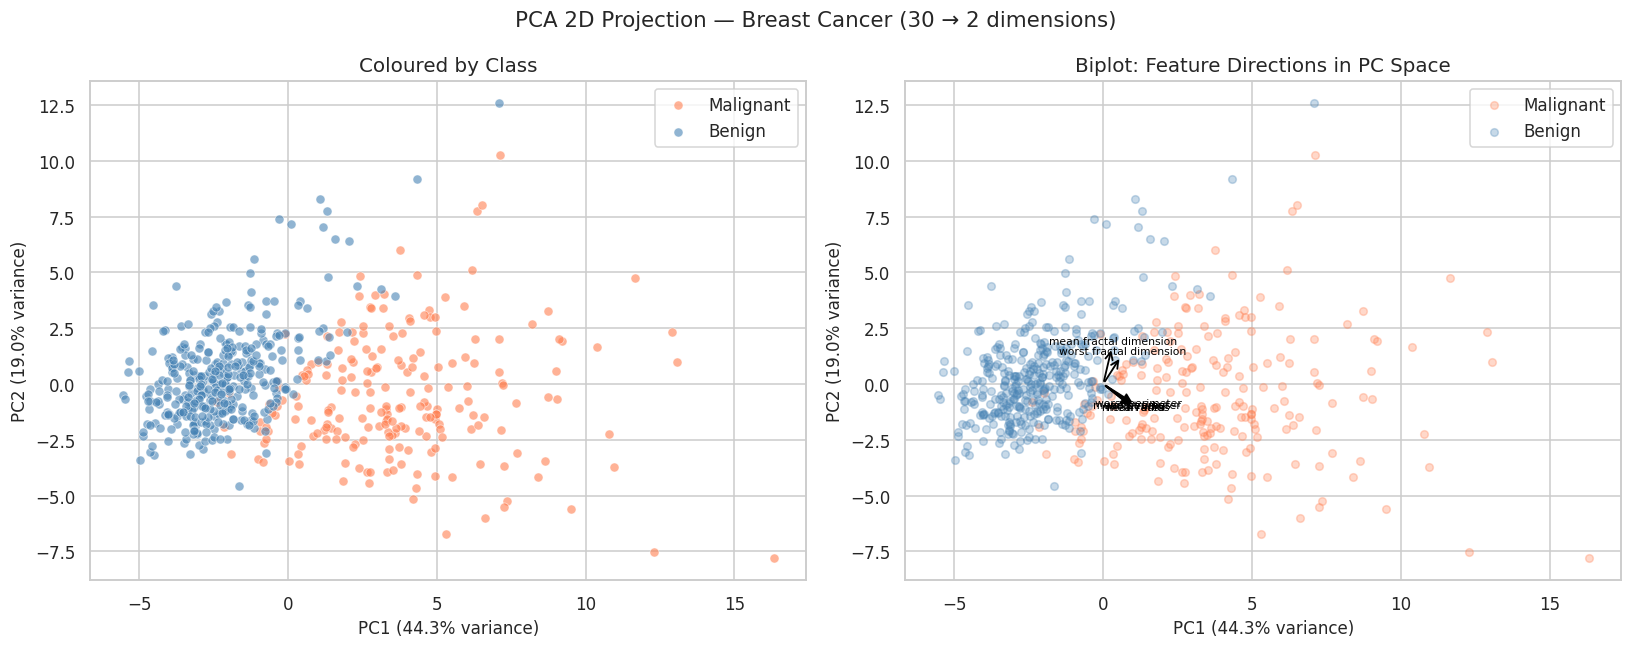

Total variance explained by 2 PCs: 63.2%
Observation: Even with only 2 components the two classes are largely separable,
confirming that the 30 features carry significant discriminative information.


In [13]:
# ── 4.2  2D PCA scatter — visualising the class structure ─────────────
# Project 30 features down to 2 principal components.
# If the classes are separable in this 2D view, a classifier should do well.

pca2 = PCA(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(X_sc)

pca_df = pd.DataFrame(X_pca2, columns=["PC1", "PC2"])
pca_df["target"] = y_bc.map({0: "Malignant", 1: "Benign"})

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("PCA 2D Projection — Breast Cancer (30 → 2 dimensions)", fontsize=14)

# ── Left: class-coloured scatter ─────────────────────────────────────
for label, color in zip(["Malignant", "Benign"], ["coral", "steelblue"]):
    mask = pca_df["target"] == label
    axes[0].scatter(pca_df.loc[mask, "PC1"], pca_df.loc[mask, "PC2"],
                    label=label, alpha=0.6, s=35, color=color, edgecolors="white", linewidth=0.5)
axes[0].set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% variance)")
axes[0].set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% variance)")
axes[0].set_title("Coloured by Class")
axes[0].legend()

# ── Right: biplot — arrows show original feature directions ──────────
loadings = pca2.components_.T
scale_factor = 4.5

for label, color in zip(["Malignant", "Benign"], ["coral", "steelblue"]):
    mask = pca_df["target"] == label
    axes[1].scatter(pca_df.loc[mask, "PC1"], pca_df.loc[mask, "PC2"],
                    label=label, alpha=0.3, s=25, color=color)

# Draw arrows for top 8 most influential features
feature_magnitudes = np.sqrt(loadings[:, 0]**2 + loadings[:, 1]**2)
top8_idx = np.argsort(feature_magnitudes)[-8:]

for idx in top8_idx:
    axes[1].annotate("", xy=(loadings[idx, 0] * scale_factor, loadings[idx, 1] * scale_factor),
                     xytext=(0, 0),
                     arrowprops=dict(arrowstyle="->", color="black", lw=1.2))
    axes[1].text(loadings[idx, 0] * scale_factor * 1.1,
                 loadings[idx, 1] * scale_factor * 1.1,
                 X_bc.columns[idx], fontsize=7, ha="center", color="black")

axes[1].set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% variance)")
axes[1].set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% variance)")
axes[1].set_title("Biplot: Feature Directions in PC Space")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Total variance explained by 2 PCs: {pca2.explained_variance_ratio_.sum()*100:.1f}%")
print("Observation: Even with only 2 components the two classes are largely separable,")
print("confirming that the 30 features carry significant discriminative information.")

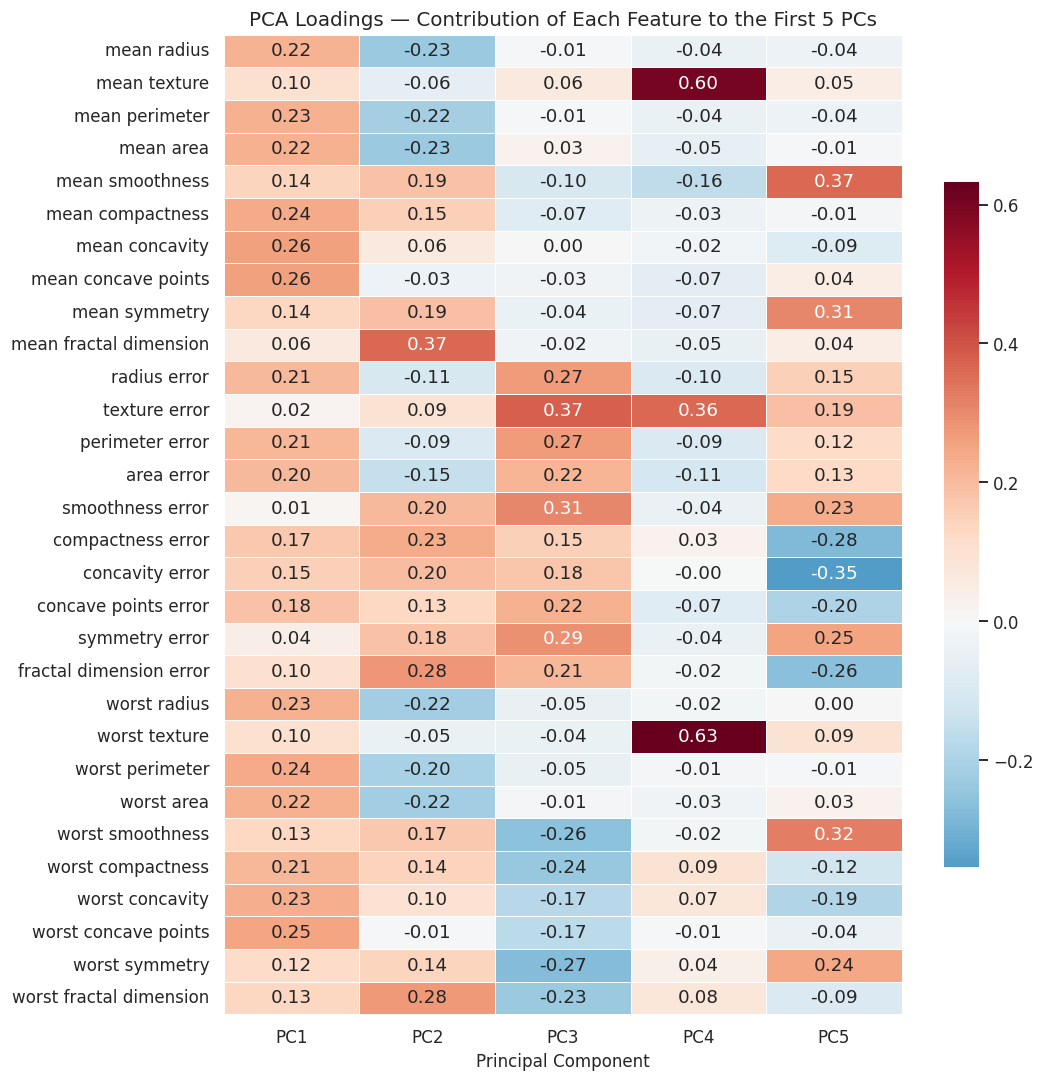

PC1 is dominated by: ['mean concave points', 'mean concavity', 'worst concave points']
PC2 is dominated by: ['mean fractal dimension', 'fractal dimension error', 'worst fractal dimension']


In [14]:
# ── 4.3  PCA loadings heatmap — what does PC1 actually represent? ─────
# Loadings show how much each original feature contributes to each component.
# Large absolute loading = that feature drives the component.

pca5 = PCA(n_components=5, random_state=42)
pca5.fit(X_sc)

loadings_df = pd.DataFrame(
    pca5.components_.T,
    index=X_bc.columns,
    columns=[f"PC{i+1}" for i in range(5)]
)

fig, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(loadings_df, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, linewidths=0.5, ax=ax, cbar_kws={"shrink": 0.7})
ax.set_title("PCA Loadings — Contribution of Each Feature to the First 5 PCs", fontsize=13)
ax.set_xlabel("Principal Component")
plt.tight_layout()
plt.show()

print("PC1 is dominated by:", loadings_df["PC1"].abs().nlargest(3).index.tolist())
print("PC2 is dominated by:", loadings_df["PC2"].abs().nlargest(3).index.tolist())

### Exercise 3
Using the **Wine dataset** (`X_wine`, `y_wine`, 3 cultivar classes):

1. Scale the data with `StandardScaler`.
2. Fit `PCA` on all 13 features. Plot **individual** and **cumulative** explained variance.
3. How many components are needed to explain at least **85%** of the variance?
4. Project the data onto the first 2 principal components and create a **scatter plot coloured by cultivar**.
5. Are the three wine classes visually separable in 2D PCA space? Write a one-sentence observation.

```python
# Your code here
```

```
# Your answer here
```

---
## Part 5 — Correlation Analysis & Redundant Feature Removal

Highly correlated features carry **the same information twice**. Keeping both:
- Does not improve model performance.
- Inflates the feature space.
- Can destabilise coefficient-based models (multicollinearity).

**Strategy:** Remove one feature from each pair with correlation > threshold (e.g., 0.90).

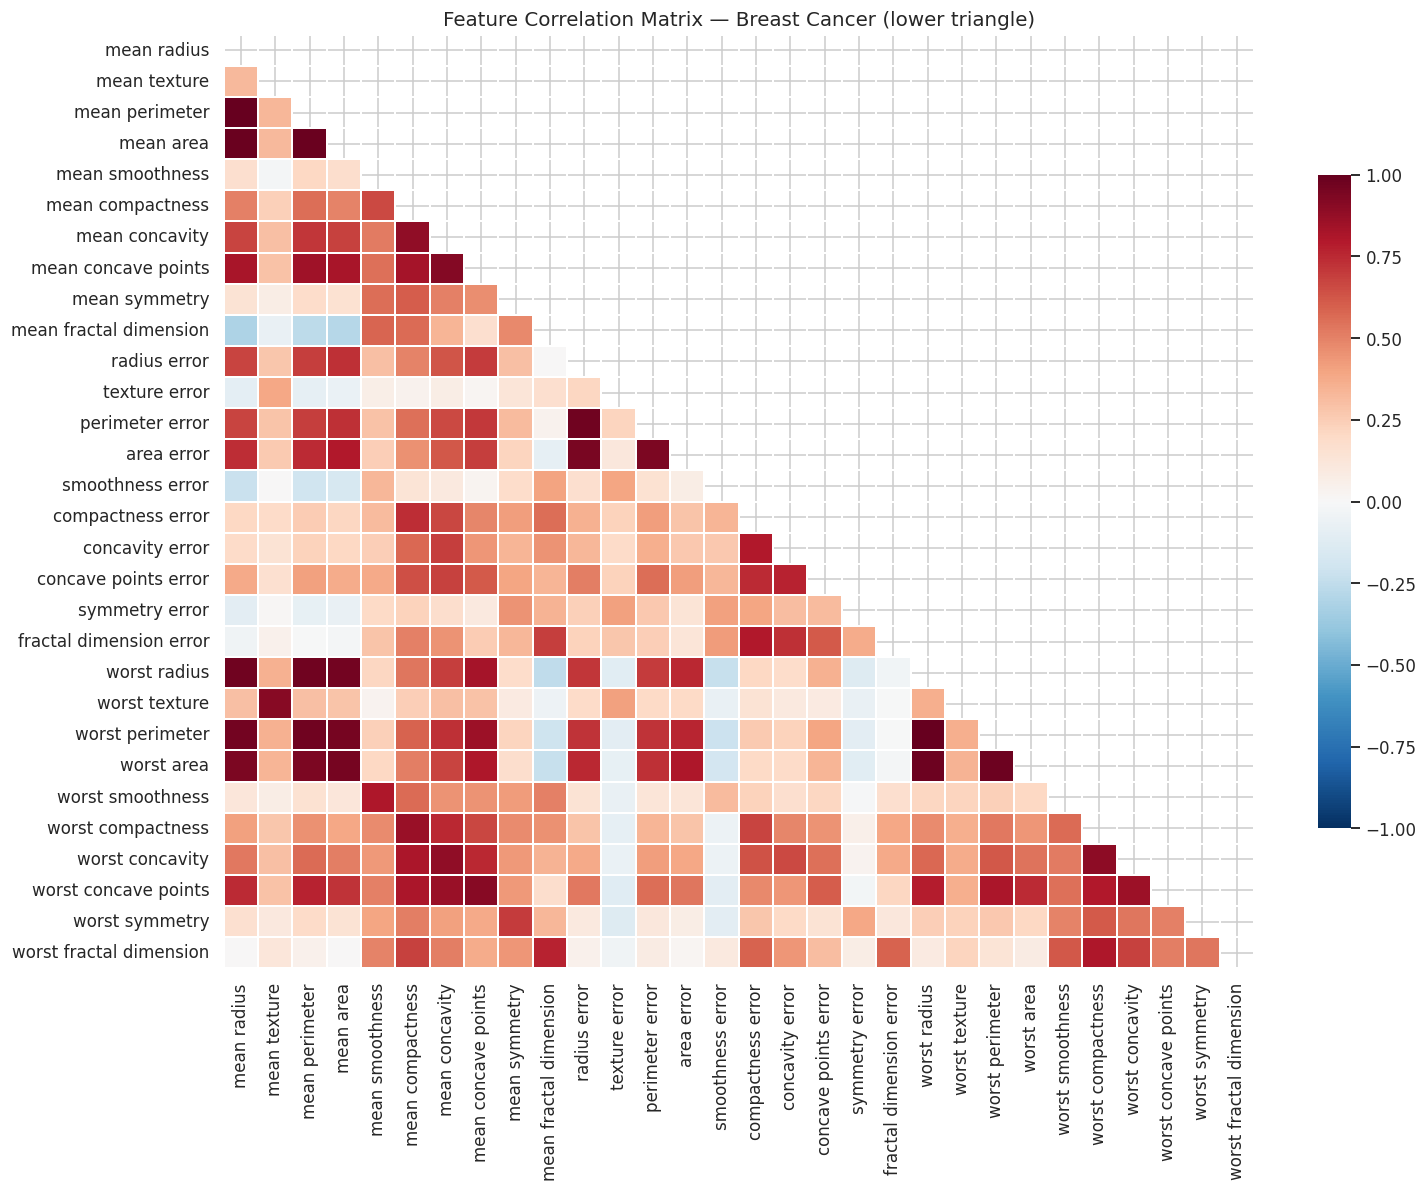

Feature pairs with |correlation| > 0.90: 21
  mean perimeter                 ↔ mean radius                     r = 0.998
  worst perimeter                ↔ worst radius                    r = 0.994
  mean area                      ↔ mean radius                     r = 0.987
  mean area                      ↔ mean perimeter                  r = 0.987
  worst area                     ↔ worst radius                    r = 0.984


In [15]:
# ── 5.1  Correlation heatmap ──────────────────────────────────────────

corr = X_bc.corr()

fig, ax = plt.subplots(figsize=(14, 11))

# Mask the upper triangle to avoid redundancy
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, annot=False, linewidths=0.3,
            ax=ax, cbar_kws={"shrink": 0.7})
ax.set_title("Feature Correlation Matrix — Breast Cancer (lower triangle)", fontsize=13)
plt.tight_layout()
plt.show()

# Count highly correlated pairs
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_corr_pairs = [(col, row, upper.loc[row, col])
                   for col in upper.columns for row in upper.index
                   if abs(upper.loc[row, col]) > 0.90]
print(f"Feature pairs with |correlation| > 0.90: {len(high_corr_pairs)}")
for a, b, r in sorted(high_corr_pairs, key=lambda x: -abs(x[2]))[:5]:
    print(f"  {a:30s} ↔ {b:30s}  r = {r:.3f}")

In [16]:
# ── 5.2  Automatic removal of highly correlated features ──────────────

def remove_correlated(df, threshold=0.90):
    """Remove one feature from each pair with |correlation| > threshold."""
    corr_matrix = df.corr().abs()
    upper       = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop     = [col for col in upper.columns if any(upper[col] > threshold)]
    return df.drop(columns=to_drop), to_drop

X_reduced, dropped = remove_correlated(X_bc, threshold=0.90)

print(f"Original features: {X_bc.shape[1]}")
print(f"Dropped {len(dropped)} highly correlated features: {dropped}")
print(f"Remaining features: {X_reduced.shape[1]}")
print(f"\nRemaining: {X_reduced.columns.tolist()}")

Original features: 30
Dropped 10 highly correlated features: ['mean perimeter', 'mean area', 'mean concave points', 'perimeter error', 'area error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst concave points']
Remaining features: 20

Remaining: ['mean radius', 'mean texture', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst symmetry', 'worst fractal dimension']


---
## Part 6 — Putting It All Together: The Preprocessing Pipeline

Scikit-learn's `Pipeline` chains preprocessing steps and a model into a single, **leak-proof** object.

Benefits:
- Guarantees scalers and selectors are fit **only on training data**.
- Makes cross-validation correct — the pipeline refits from scratch on each fold.
- Simplifies deployment: one object handles all preprocessing + prediction.

> **Common mistake:** Scaling or selecting features before splitting into train/test splits data leakage — the test set influences your preprocessing, artificially boosting performance metrics.

In [17]:
# ── 6.1  Pipeline: Scale → Select → Classify ──────────────────────────
# Compare three setups to see how preprocessing affects cross-validated accuracy.

from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipelines = {
    "No preprocessing": Pipeline([
        ("clf", LogisticRegression(max_iter=5000, random_state=42))
    ]),
    "Scale only": Pipeline([
        ("scaler", StandardScaler()),
        ("clf",    LogisticRegression(max_iter=5000, random_state=42))
    ]),
    "Scale + Select (k=10)": Pipeline([
        ("scaler",   StandardScaler()),
        ("selector", SelectKBest(f_classif, k=10)),
        ("clf",      LogisticRegression(max_iter=5000, random_state=42))
    ]),
    "Scale + PCA (n=10)": Pipeline([
        ("scaler", StandardScaler()),
        ("pca",    PCA(n_components=10, random_state=42)),
        ("clf",    LogisticRegression(max_iter=5000, random_state=42))
    ]),
}

results = {}
for name, pipe in pipelines.items():
    scores = cross_val_score(pipe, X_bc, y_bc, cv=cv, scoring="accuracy")
    results[name] = scores
    print(f"{name:30s}  accuracy = {scores.mean():.4f} ± {scores.std():.4f}")

No preprocessing                accuracy = 0.9543 ± 0.0187
Scale only                      accuracy = 0.9737 ± 0.0166
Scale + Select (k=10)           accuracy = 0.9508 ± 0.0162
Scale + PCA (n=10)              accuracy = 0.9772 ± 0.0070


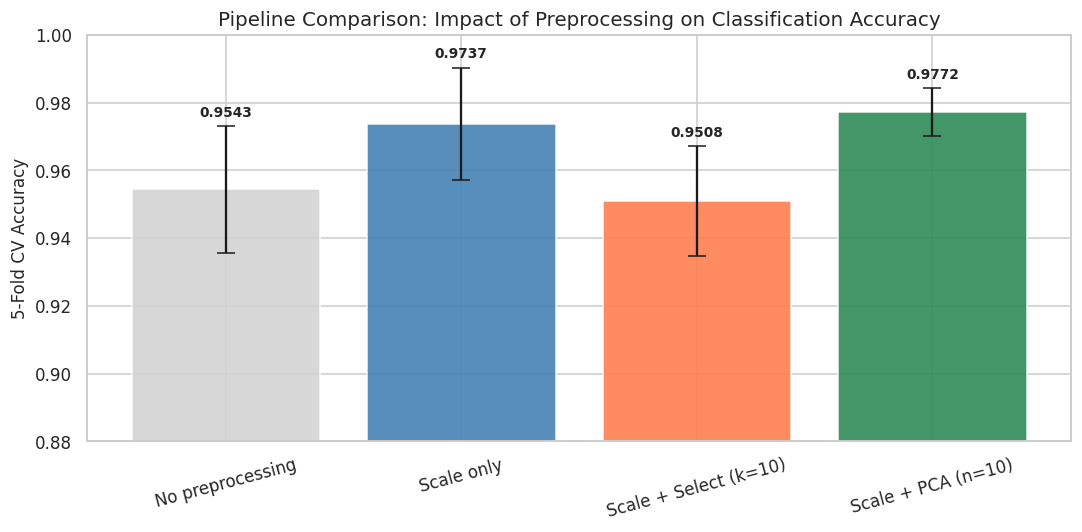

Best pipeline: 'Scale + PCA (n=10)' with accuracy 0.9772


In [18]:
# ── 6.2  Visualise the pipeline comparison ────────────────────────────

fig, ax = plt.subplots(figsize=(10, 5))

names  = list(results.keys())
means  = [s.mean() for s in results.values()]
stds   = [s.std()  for s in results.values()]
colors = ["lightgrey", "steelblue", "coral", "seagreen"]

bars = ax.bar(names, means, yerr=stds, capsize=6,
              color=colors, edgecolor="white", alpha=0.9)

ax.set_ylim(0.88, 1.0)
ax.set_ylabel("5-Fold CV Accuracy")
ax.set_title("Pipeline Comparison: Impact of Preprocessing on Classification Accuracy")
ax.tick_params(axis="x", rotation=15)

for bar, mean, std in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + std + 0.002,
            f"{mean:.4f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()

best = max(results, key=lambda k: results[k].mean())
print(f"Best pipeline: '{best}' with accuracy {results[best].mean():.4f}")

### Exercise 4
Using the **Wine dataset** (`X_wine`, `y_wine`):

1. Build **four pipelines** with a `LogisticRegression` classifier:
   - No preprocessing
   - `StandardScaler` only
   - `StandardScaler` + `SelectKBest(k=7)`
   - `MinMaxScaler` + `PCA(n_components=5)`
2. Evaluate each with **5-fold stratified cross-validation** using accuracy.
3. Plot the results as a bar chart with error bars (mean ± std).
4. Which pipeline performs best? Does preprocessing improve accuracy noticeably compared to no preprocessing? Why might this be?

```python
# Your code here
```

```
# Your answer here
```

---
## Part 7 — The Full Preprocessing Dashboard: Storytelling

Just as we built an EDA storytelling dashboard with four plots, we can build a **preprocessing insight dashboard** that documents what we learned about the data before modelling.

**Storytelling checklist:**
1. **Scale problem** — do features have wildly different ranges?
2. **Informative features** — which features carry the most signal?
3. **Redundancy** — which features are highly correlated?
4. **Structure** — does PCA reveal separable class clusters?

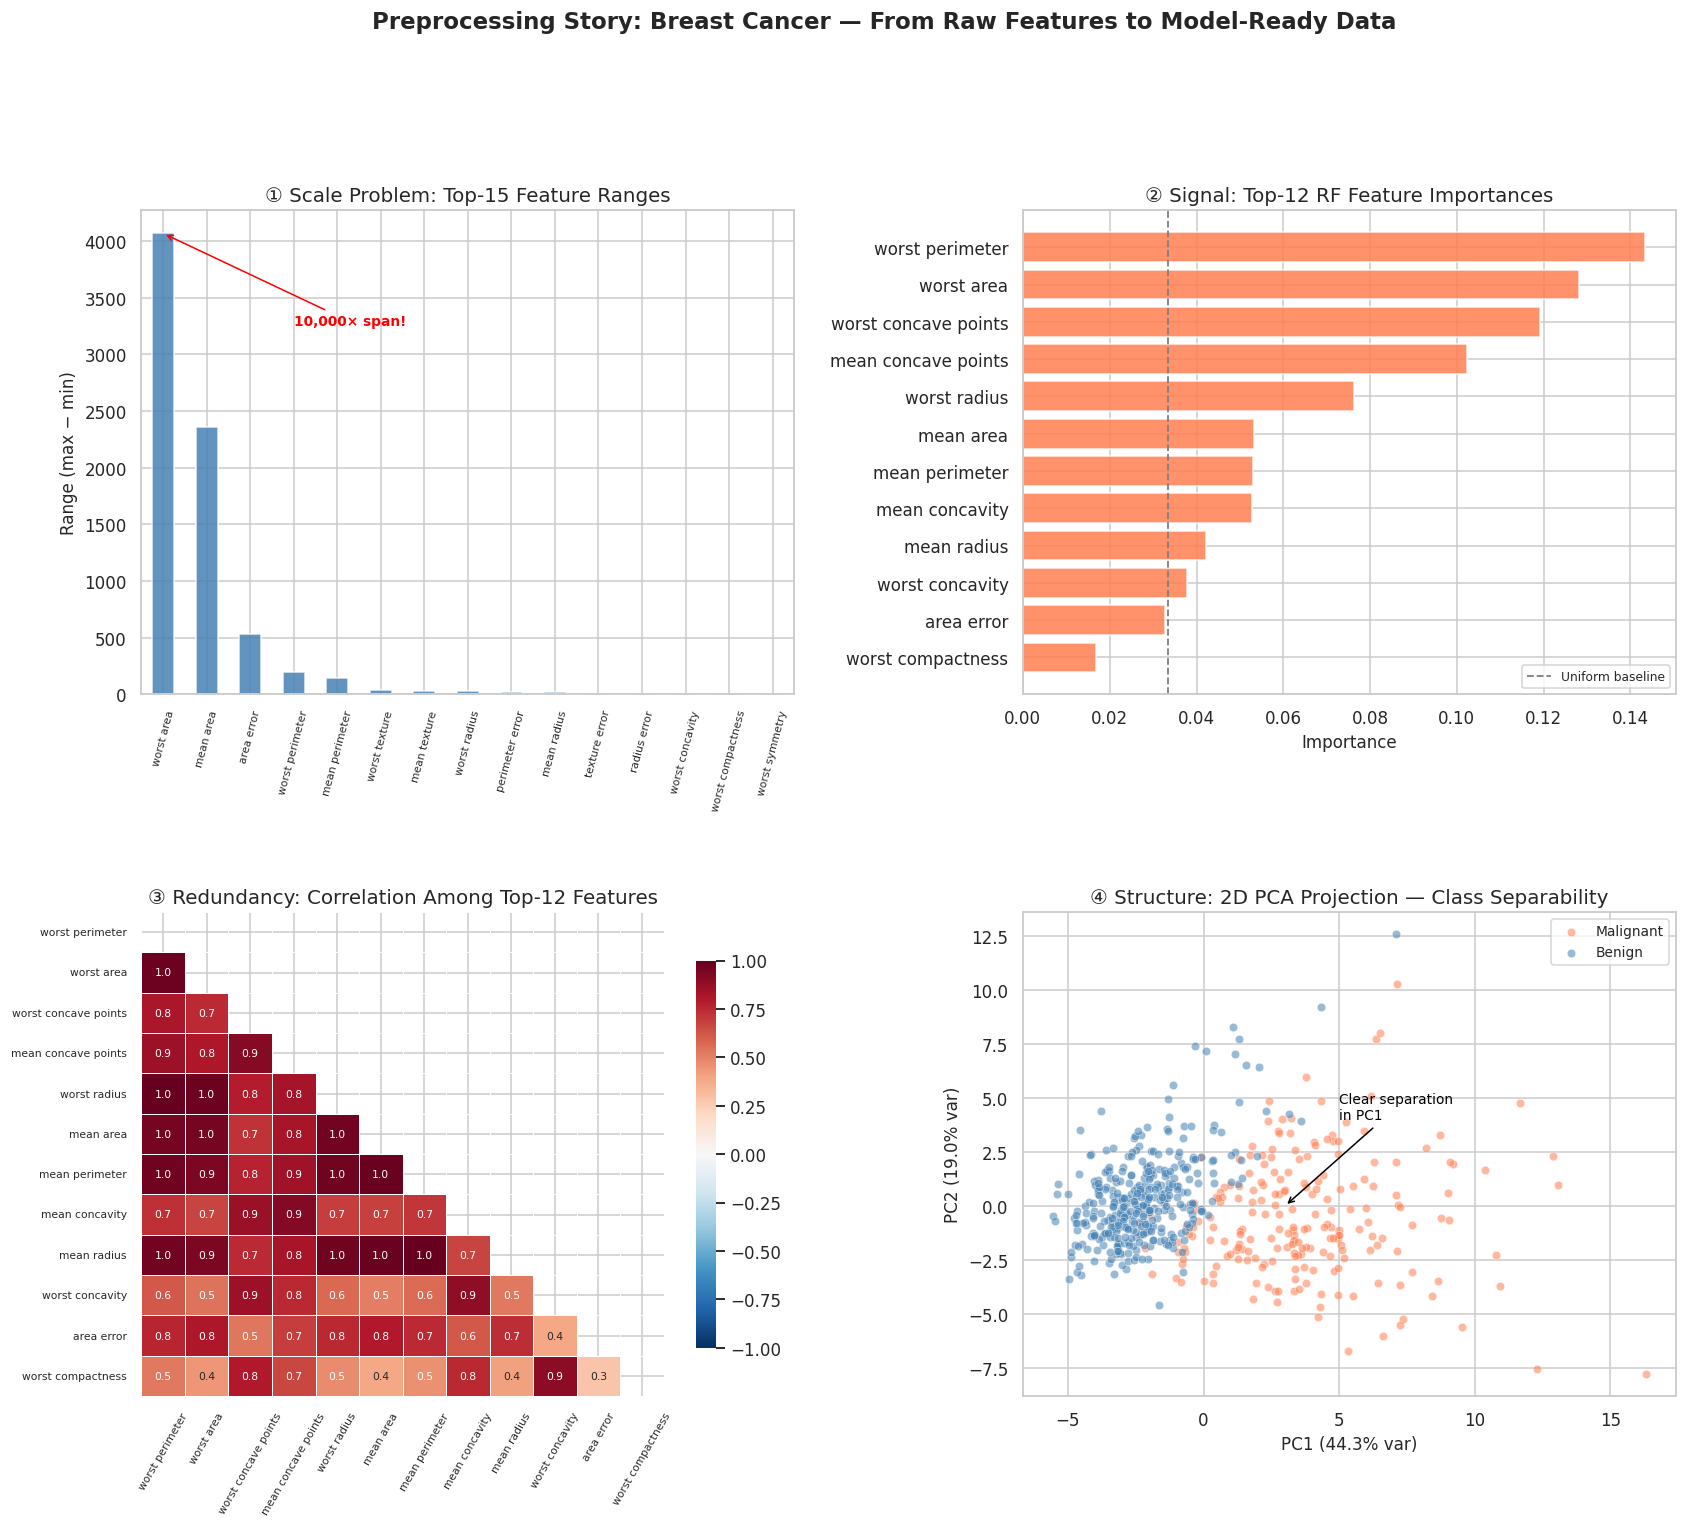

Dashboard saved as preprocessing_dashboard.png


In [19]:
# ── 7.1  The Preprocessing Dashboard ─────────────────────────────────

fig = plt.figure(figsize=(18, 14))
fig.suptitle("Preprocessing Story: Breast Cancer — From Raw Features to Model-Ready Data",
             fontsize=15, fontweight="bold", y=1.01)

gs = gridspec.GridSpec(2, 2, hspace=0.45, wspace=0.35)

# ── Panel 1: Feature ranges — the scale problem ───────────────────────
ax1 = fig.add_subplot(gs[0, 0])
feature_ranges.sort_values(ascending=False)[:15].plot(
    kind="bar", color="steelblue", edgecolor="white", alpha=0.85, ax=ax1)
ax1.set_title("① Scale Problem: Top-15 Feature Ranges")
ax1.set_ylabel("Range (max − min)")
ax1.tick_params(axis="x", rotation=75, labelsize=7)
ax1.annotate("10,000× span!", xy=(0, feature_ranges.max()),
             fontsize=9, color="red", fontweight="bold",
             xytext=(3, feature_ranges.max() * 0.8),
             arrowprops=dict(arrowstyle="->", color="red"))

# ── Panel 2: Feature importance (RF) — signal vs noise ───────────────
ax2 = fig.add_subplot(gs[0, 1])
top12 = rf_importance.head(12)
ax2.barh(top12["feature"][::-1], top12["importance"][::-1],
         color="coral", edgecolor="white", alpha=0.85)
ax2.axvline(1 / len(X_bc.columns), color="grey", linestyle="--",
            linewidth=1.2, label="Uniform baseline")
ax2.set_title("② Signal: Top-12 RF Feature Importances")
ax2.set_xlabel("Importance")
ax2.legend(fontsize=8)

# ── Panel 3: Correlation heatmap — redundancy ─────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
top_feats = rf_importance["feature"][:12].tolist()
corr_sub  = X_bc[top_feats].corr()
mask_sub  = np.triu(np.ones_like(corr_sub, dtype=bool))
sns.heatmap(corr_sub, mask=mask_sub, cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, linewidths=0.4, ax=ax3, cbar_kws={"shrink": 0.8},
            annot=True, fmt=".1f", annot_kws={"size": 7})
ax3.set_title("③ Redundancy: Correlation Among Top-12 Features")
ax3.tick_params(axis="x", rotation=60, labelsize=7)
ax3.tick_params(axis="y", labelsize=7)

# ── Panel 4: PCA 2D — class separability ──────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
for label, color in zip(["Malignant", "Benign"], ["coral", "steelblue"]):
    mask = pca_df["target"] == label
    ax4.scatter(pca_df.loc[mask, "PC1"], pca_df.loc[mask, "PC2"],
                label=label, alpha=0.55, s=30, color=color,
                edgecolors="white", linewidth=0.4)
ax4.set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% var)")
ax4.set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% var)")
ax4.set_title("④ Structure: 2D PCA Projection — Class Separability")
ax4.legend(fontsize=9)
ax4.annotate("Clear separation\nin PC1", xy=(3, 0),
             xytext=(5, 4), fontsize=9, color="black",
             arrowprops=dict(arrowstyle="->", color="black"))

plt.tight_layout()
plt.savefig("preprocessing_dashboard.png", dpi=110, bbox_inches="tight")
plt.show()
print("Dashboard saved as preprocessing_dashboard.png")

### Exercise 5 — Final Challenge

Using the **Wine dataset** (`X_wine`, `y_wine`, 13 features, 3 classes), build your own **Preprocessing Dashboard** that tells the full preprocessing story.

1. **Panel 1 (Scale problem):** Bar chart of feature ranges — sorted descending.
2. **Panel 2 (Feature importance):** Random Forest importances — horizontal bar chart.
3. **Panel 3 (Correlation):** Heatmap of the top-8 most important features.
4. **Panel 4 (PCA 2D):** Scatter plot coloured by cultivar class.
5. Combine all four panels in a `2×2` `GridSpec` figure with a headline title.
6. Add **at least one annotation** on any panel highlighting the most important insight.
7. Write 3–4 sentences below the dashboard summarising:
   - Is scaling necessary for this dataset?
   - Which features carry the most signal?
   - Are the three wine classes separable in 2D PCA space?
   - What preprocessing pipeline would you recommend before modelling?

```python
# Your code here
```

```
# Your answer here
```

---
## Summary

| Concept | What it solves | Key tools |
|---|---|---|
| **StandardScaler** | Features on different scales | `sklearn.preprocessing.StandardScaler` |
| **MinMaxScaler** | Need values in $[0, 1]$ | `sklearn.preprocessing.MinMaxScaler` |
| **RobustScaler** | Outliers distort the mean/std | `sklearn.preprocessing.RobustScaler` |
| **Filter selection** | Fast removal of irrelevant features | `SelectKBest`, `f_classif`, `mutual_info_classif` |
| **Wrapper selection** | Model-guided iterative selection | `RFE` |
| **Embedded selection** | Selection built into model training | `RandomForestClassifier.feature_importances_` |
| **Correlation pruning** | Remove redundant features | Pearson correlation matrix |
| **PCA** | Visualise and compress high-dimensional data | `sklearn.decomposition.PCA` |
| **Pipeline** | Leak-proof end-to-end preprocessing + model | `sklearn.pipeline.Pipeline` |

---
**The preprocessing decision loop:**
1. Check feature scales → choose the right scaler  
2. Score features (filter) → remove obvious noise  
3. Check correlations → remove redundancy  
4. Visualise with PCA → confirm class structure  
5. Wrap everything in a `Pipeline` → evaluate with cross-validation  
6. Iterate: does removing more features help or hurt?